In [1]:
import sys
from pathlib import Path
import json
import math
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.stats import spearmanr, pearsonr

def find_project_root(marker="data/imagenet100"):
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root containing {marker}")

PROJECT_ROOT = find_project_root()
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [2]:
class AsymmetricBilinearClassifier(nn.Module):
    def __init__(self, embed_dim=2048, n_classes=100, gamma=1.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_classes = n_classes
        self.gamma = gamma
        self.Q = nn.Parameter(torch.eye(embed_dim))
        self.R = nn.Parameter(torch.zeros(embed_dim, embed_dim))
        self.prototypes = nn.Parameter(torch.empty(n_classes, embed_dim))
        nn.init.kaiming_uniform_(self.prototypes, a=math.sqrt(5))
    def compute_M(self):
        S = (self.Q + self.Q.T) / 2
        A = (self.R - self.R.T) / 2
        return S + self.gamma * A, S, A
    def forward(self, x):
        M, _, _ = self.compute_M()
        return (x @ M) @ self.prototypes.T
    def internal_representation(self, x):
        """The transformed embedding x @ M (before dotting with prototypes)."""
        M, _, _ = self.compute_M()
        return x @ M


class TverskyProjectionLayer(nn.Module):
    def __init__(self, embed_dim=2048, n_classes=100, n_features=224):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_classes = n_classes
        self.n_features = n_features
        self.feature_bank = nn.Parameter(torch.empty(n_features, embed_dim))
        nn.init.uniform_(self.feature_bank, -0.1, 0.1)
        self.prototypes = nn.Parameter(torch.empty(n_classes, embed_dim))
        nn.init.uniform_(self.prototypes, -0.1, 0.1)
        self.epsilon = nn.Parameter(torch.tensor(1.0))
        self.theta = nn.Parameter(torch.tensor(1.0))
        self.omega = nn.Parameter(torch.tensor(1.0))
    def forward(self, x):
        B, F_n, C = x.size(0), self.n_features, self.n_classes
        X = x @ self.feature_bank.T
        Y = self.prototypes @ self.feature_bank.T
        X_active = (X > 0).float()
        Y_active = (Y > 0).float()
        X_bcf = X.unsqueeze(1).expand(B, C, F_n)
        Y_bcf = Y.unsqueeze(0).expand(B, C, F_n)
        X_act = X_active.unsqueeze(1).expand(B, C, F_n)
        Y_act = Y_active.unsqueeze(0).expand(B, C, F_n)
        both = X_act * Y_act
        f_intersect = (X_bcf * Y_bcf * both).sum(dim=2)
        only_X = X_act * (1 - Y_act)
        f_X = (X_bcf * only_X).sum(dim=2) + ((X_bcf - Y_bcf) * (both * (X_bcf > Y_bcf).float())).sum(dim=2)
        only_Y = Y_act * (1 - X_act)
        f_Y = (Y_bcf * only_Y).sum(dim=2) + ((Y_bcf - X_bcf) * (both * (Y_bcf > X_bcf).float())).sum(dim=2)
        return self.omega * f_intersect - self.epsilon * f_X - self.theta * f_Y
    def internal_representation(self, x):
        """The feature activation vector x @ Φ.T (the 224-dim feature membership)."""
        return x @ self.feature_bank.T


print("Model classes defined.")

Model classes defined.


In [3]:
print("Checkpoints available:")
for p in sorted(CHECKPOINTS_DIR.glob("*.pt")):
    print(f"  {p.name}")

Checkpoints available:
  analysis_asymmetric_seed42.pt
  analysis_tversky_seed42.pt
  cosine_prototype_classifier.pt
  linear_classifier.pt
  proposed_asymmetric_g1.0_l0.pt
  tversky_F224_10ep.pt
  tversky_F224_30ep.pt


In [4]:
def load_embeddings(split):
    data = torch.load(EMBEDDINGS_DIR / f"{split}_embeddings.pt", weights_only=True)
    return data["features"], data["labels"]

train_features, train_labels = load_embeddings("train")
heldout_features, heldout_labels = load_embeddings("heldout")

with open(EMBEDDINGS_DIR / "label_mapping.json") as f:
    label_mapping = json.load(f)
idx_to_name = {int(k): v for k, v in label_mapping["idx_to_name"].items()}
idx_to_synset = {int(k): v for k, v in label_mapping["idx_to_synset"].items()}

print(f"Train: {train_features.shape}, Heldout: {heldout_features.shape}")

Train: torch.Size([117000, 2048]), Heldout: torch.Size([5000, 2048])


In [5]:
from torch.utils.data import TensorDataset, DataLoader
import time

train_ds = TensorDataset(train_features, train_labels)
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True, num_workers=0)

def quick_train(model, n_epochs, lr=1e-3, wd=1e-4):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    for ep in range(n_epochs):
        model.train()
        for f, l in train_loader:
            f, l = f.to(device), l.to(device)
            loss = crit(model(f), l)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

# Asymmetric model, seed 42, 20 epochs (matches held-out eval)
torch.manual_seed(42)
asym_model = quick_train(AsymmetricBilinearClassifier(2048, 100, gamma=1.0), n_epochs=20)
torch.save({"model_state_dict": asym_model.state_dict(), "seed": 42, "gamma": 1.0},
           CHECKPOINTS_DIR / "analysis_asymmetric_seed42.pt")
print("Asymmetric model trained and saved.")

# Tversky model, seed 42, 10 epochs (where it peaked)
torch.manual_seed(42)
tversky_model = quick_train(TverskyProjectionLayer(2048, 100, n_features=224), n_epochs=10)
torch.save({"model_state_dict": tversky_model.state_dict(), "seed": 42, "n_features": 224},
           CHECKPOINTS_DIR / "analysis_tversky_seed42.pt")
print("Tversky model trained and saved.")

Asymmetric model trained and saved.
Tversky model trained and saved.


In [6]:
# Set both models to eval mode
asym_model.eval()
tversky_model.eval()

# Pick one random image per class from held-out
torch.manual_seed(42)  # reproducible selection

selected_indices = []
for class_idx in range(100):
    # Indices of all held-out images belonging to this class
    class_mask = (heldout_labels == class_idx).nonzero(as_tuple=True)[0]
    # Pick one at random
    chosen = class_mask[torch.randint(len(class_mask), (1,))].item()
    selected_indices.append(chosen)

selected_indices = torch.tensor(selected_indices)
selected_features = heldout_features[selected_indices].to(device)  # [100, 2048]
selected_labels = heldout_labels[selected_indices]                  # [100]

print(f"Selected {len(selected_indices)} images, one per class")
print(f"Selected features shape: {selected_features.shape}")
print(f"Labels (should be 0-99, each once): {selected_labels.tolist()[:10]}... ")
print(f"All 100 classes present: {len(torch.unique(selected_labels)) == 100}")

Selected 100 images, one per class
Selected features shape: torch.Size([100, 2048])
Labels (should be 0-99, each once): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]... 
All 100 classes present: True


In [7]:
with torch.no_grad():
    # Asymmetric model
    asym_logits = asym_model(selected_features)                    # [100, 100]
    asym_internal = asym_model.internal_representation(selected_features)  # [100, 2048]
    
    # Tversky model
    tversky_logits = tversky_model(selected_features)              # [100, 100]
    tversky_internal = tversky_model.internal_representation(selected_features)  # [100, 224]

# Move to CPU for numpy/scipy
asym_logits = asym_logits.cpu()
asym_internal = asym_internal.cpu()
tversky_logits = tversky_logits.cpu()
tversky_internal = tversky_internal.cpu()

print("Representation shapes:")
print(f"  Asymmetric logits:   {tuple(asym_logits.shape)}")
print(f"  Asymmetric internal: {tuple(asym_internal.shape)}")
print(f"  Tversky logits:      {tuple(tversky_logits.shape)}")
print(f"  Tversky internal:    {tuple(tversky_internal.shape)}")

Representation shapes:
  Asymmetric logits:   (100, 100)
  Asymmetric internal: (100, 2048)
  Tversky logits:      (100, 100)
  Tversky internal:    (100, 224)


In [8]:
def cosine_similarity_matrix(X):
    """Compute the NxN cosine similarity matrix for N row vectors."""
    X_norm = F.normalize(X, p=2, dim=1)
    return (X_norm @ X_norm.T)


def upper_triangle(M):
    """Extract the upper triangle (excluding diagonal) as a flat vector."""
    n = M.shape[0]
    iu = torch.triu_indices(n, n, offset=1)  # indices above diagonal
    return M[iu[0], iu[1]]


# Build the four similarity matrices
sim_asym_logits = cosine_similarity_matrix(asym_logits)
sim_asym_internal = cosine_similarity_matrix(asym_internal)
sim_tversky_logits = cosine_similarity_matrix(tversky_logits)
sim_tversky_internal = cosine_similarity_matrix(tversky_internal)

# Extract upper triangles (100*99/2 = 4950 pairwise similarities each)
tri_asym_logits = upper_triangle(sim_asym_logits).numpy()
tri_asym_internal = upper_triangle(sim_asym_internal).numpy()
tri_tversky_logits = upper_triangle(sim_tversky_logits).numpy()
tri_tversky_internal = upper_triangle(sim_tversky_internal).numpy()

print(f"Each upper triangle has {len(tri_asym_logits)} pairwise similarities\n")

# === RSA in LOGIT space ===
r_pearson_logit, p_pearson_logit = pearsonr(tri_asym_logits, tri_tversky_logits)
r_spearman_logit, p_spearman_logit = spearmanr(tri_asym_logits, tri_tversky_logits)

print("=" * 60)
print("RSA in LOGIT space (Asymmetric vs Tversky)")
print("=" * 60)
print(f"  Pearson r:  {r_pearson_logit:.4f}  (p = {p_pearson_logit:.2e})")
print(f"  Spearman ρ: {r_spearman_logit:.4f}  (p = {p_spearman_logit:.2e})")

# === RSA in INTERNAL space ===
r_pearson_int, p_pearson_int = pearsonr(tri_asym_internal, tri_tversky_internal)
r_spearman_int, p_spearman_int = spearmanr(tri_asym_internal, tri_tversky_internal)

print("\n" + "=" * 60)
print("RSA in INTERNAL space (Asymmetric x@M vs Tversky x@Φ.T)")
print("=" * 60)
print(f"  Pearson r:  {r_pearson_int:.4f}  (p = {p_pearson_int:.2e})")
print(f"  Spearman ρ: {r_spearman_int:.4f}  (p = {p_spearman_int:.2e})")

Each upper triangle has 4950 pairwise similarities

RSA in LOGIT space (Asymmetric vs Tversky)
  Pearson r:  0.7495  (p = 0.00e+00)
  Spearman ρ: 0.7244  (p = 0.00e+00)

RSA in INTERNAL space (Asymmetric x@M vs Tversky x@Φ.T)
  Pearson r:  0.7693  (p = 0.00e+00)
  Spearman ρ: 0.6959  (p = 0.00e+00)


In [9]:
# Raw Barlow Twins similarity (input to both models — same for both)
sim_raw = cosine_similarity_matrix(selected_features.cpu())
tri_raw = upper_triangle(sim_raw).numpy()

def rsa(a, b):
    return spearmanr(a, b)[0]

print("Calibration references (Spearman ρ):\n")
print("How much does each representation resemble the raw Barlow Twins input?")
print(f"  Asym logits   vs raw BT: {rsa(tri_asym_logits, tri_raw):.4f}")
print(f"  Asym internal vs raw BT: {rsa(tri_asym_internal, tri_raw):.4f}")
print(f"  Tversky logits   vs raw BT: {rsa(tri_tversky_logits, tri_raw):.4f}")
print(f"  Tversky internal vs raw BT: {rsa(tri_tversky_internal, tri_raw):.4f}")

print("\nWithin-model: how much does logit space resemble internal space?")
print(f"  Asym:    logit vs internal: {rsa(tri_asym_logits, tri_asym_internal):.4f}")
print(f"  Tversky: logit vs internal: {rsa(tri_tversky_logits, tri_tversky_internal):.4f}")

print("\nCross-model (the main result):")
print(f"  Logit space:    Asym vs Tversky: {rsa(tri_asym_logits, tri_tversky_logits):.4f}")
print(f"  Internal space: Asym vs Tversky: {rsa(tri_asym_internal, tri_tversky_internal):.4f}")

Calibration references (Spearman ρ):

How much does each representation resemble the raw Barlow Twins input?
  Asym logits   vs raw BT: 0.3780
  Asym internal vs raw BT: 0.5015
  Tversky logits   vs raw BT: 0.3858
  Tversky internal vs raw BT: 0.6247

Within-model: how much does logit space resemble internal space?
  Asym:    logit vs internal: 0.9188
  Tversky: logit vs internal: 0.7514

Cross-model (the main result):
  Logit space:    Asym vs Tversky: 0.7244
  Internal space: Asym vs Tversky: 0.6959


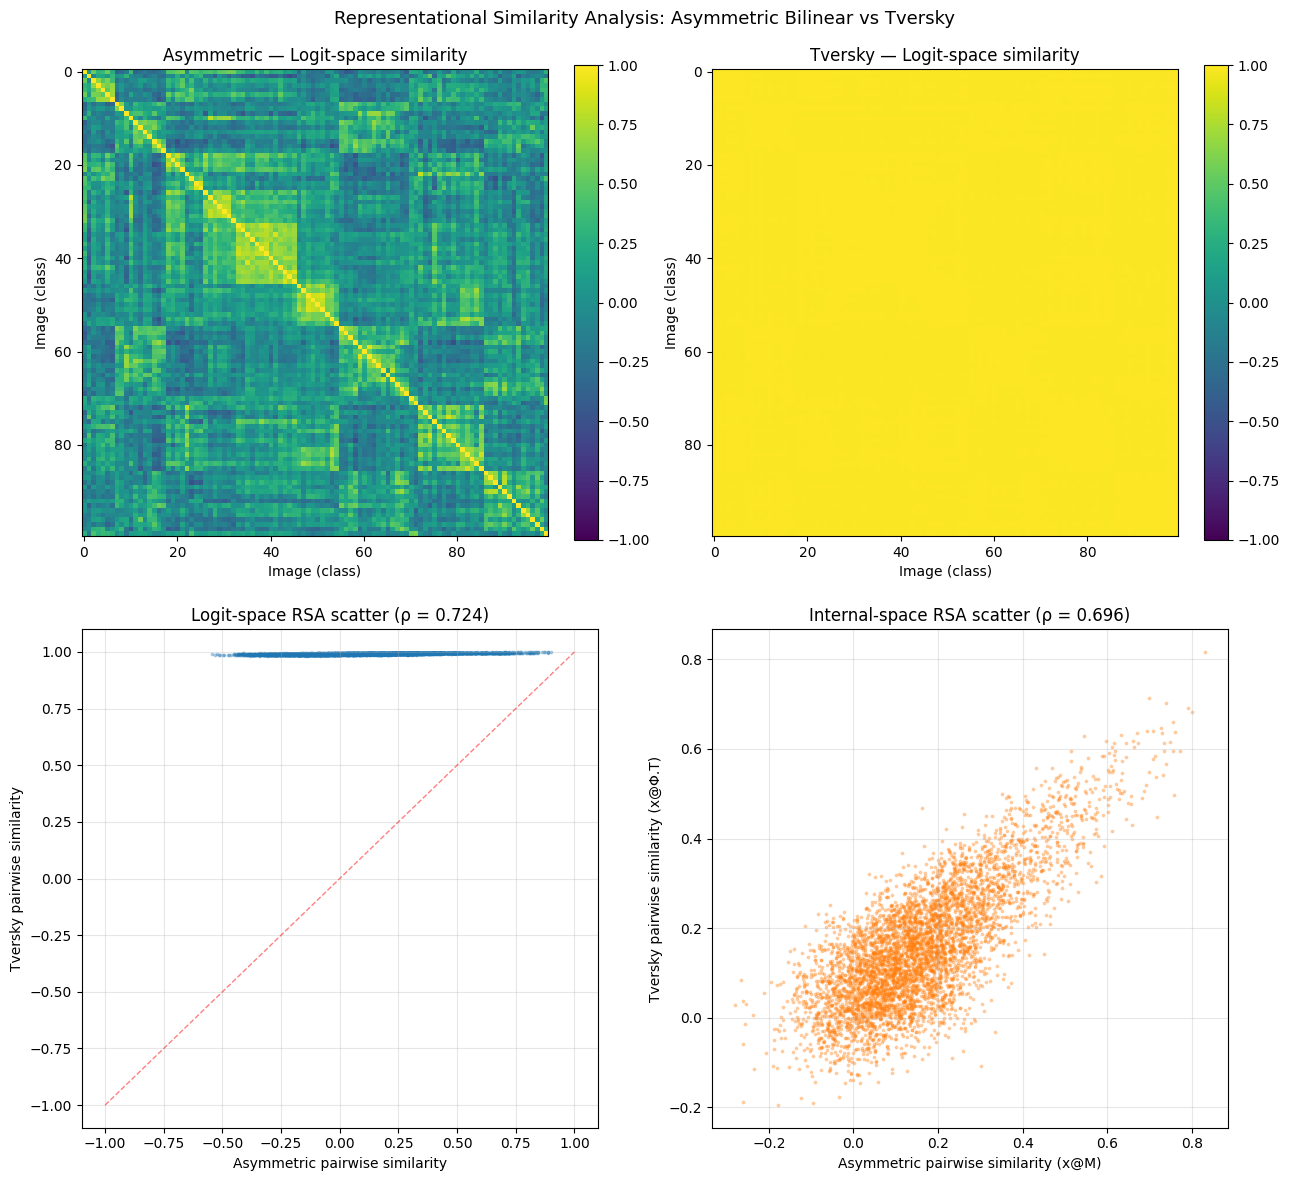

Saved to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/rsa_comparison.png


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 12))

# Top row: similarity matrices in logit space
im0 = axes[0, 0].imshow(sim_asym_logits.numpy(), cmap="viridis", vmin=-1, vmax=1)
axes[0, 0].set_title("Asymmetric — Logit-space similarity")
axes[0, 0].set_xlabel("Image (class)")
axes[0, 0].set_ylabel("Image (class)")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(sim_tversky_logits.numpy(), cmap="viridis", vmin=-1, vmax=1)
axes[0, 1].set_title("Tversky — Logit-space similarity")
axes[0, 1].set_xlabel("Image (class)")
axes[0, 1].set_ylabel("Image (class)")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# Bottom-left: scatter of the two triangles (logit space)
axes[1, 0].scatter(tri_asym_logits, tri_tversky_logits, s=3, alpha=0.3)
axes[1, 0].set_xlabel("Asymmetric pairwise similarity")
axes[1, 0].set_ylabel("Tversky pairwise similarity")
axes[1, 0].set_title(f"Logit-space RSA scatter (ρ = {r_spearman_logit:.3f})")
axes[1, 0].plot([-1, 1], [-1, 1], "r--", alpha=0.5, linewidth=1)
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: scatter of the two triangles (internal space)
axes[1, 1].scatter(tri_asym_internal, tri_tversky_internal, s=3, alpha=0.3, color="C1")
axes[1, 1].set_xlabel("Asymmetric pairwise similarity (x@M)")
axes[1, 1].set_ylabel("Tversky pairwise similarity (x@Φ.T)")
axes[1, 1].set_title(f"Internal-space RSA scatter (ρ = {r_spearman_int:.3f})")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Representational Similarity Analysis: Asymmetric Bilinear vs Tversky", fontsize=13)
plt.tight_layout()

plot_path = RESULTS_DIR / "rsa_comparison.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved to {plot_path}")

In [14]:
rsa_results = {
    "logit_space": {
        "pearson": float(r_pearson_logit), "spearman": float(r_spearman_logit),
    },
    "internal_space": {
        "pearson": float(r_pearson_int), "spearman": float(r_spearman_int),
    },
    "calibration": {
        "asym_logit_vs_raw": float(rsa(tri_asym_logits, tri_raw)),
        "asym_internal_vs_raw": float(rsa(tri_asym_internal, tri_raw)),
        "tversky_logit_vs_raw": float(rsa(tri_tversky_logits, tri_raw)),
        "tversky_internal_vs_raw": float(rsa(tri_tversky_internal, tri_raw)),
        "asym_logit_vs_internal": float(rsa(tri_asym_logits, tri_asym_internal)),
        "tversky_logit_vs_internal": float(rsa(tri_tversky_logits, tri_tversky_internal)),
    },
    "n_images": 100,
    "seed": 42,
}
with open(RESULTS_DIR / "rsa_results.json", "w") as f:
    json.dump(rsa_results, f, indent=2)
print("Saved RSA results.")

Saved RSA results.


In [17]:
def centered_cosine_similarity_matrix(X):
    """
    Cosine similarity after mean-centering each row.
    This removes any constant offset shared across all dimensions,
    which is the right choice for RSA on logit vectors.
    Equivalent to Pearson correlation between the row vectors.
    """
    X_centered = X - X.mean(dim=1, keepdim=True)
    X_norm = F.normalize(X_centered, p=2, dim=1)
    return X_norm @ X_norm.T


# Recompute logit-space matrices with centering
sim_asym_logits_c = centered_cosine_similarity_matrix(asym_logits)
sim_tversky_logits_c = centered_cosine_similarity_matrix(tversky_logits)

tri_asym_logits_c = upper_triangle(sim_asym_logits_c).numpy()
tri_tversky_logits_c = upper_triangle(sim_tversky_logits_c).numpy()

# Check Tversky's centered logit similarities are no longer degenerate
print("Tversky centered-logit similarity stats:")
print(f"  mean={tri_tversky_logits_c.mean():.3f}, std={tri_tversky_logits_c.std():.3f}, "
      f"range=[{tri_tversky_logits_c.min():.3f}, {tri_tversky_logits_c.max():.3f}]")
print("  (If std is now substantial, the degeneracy is fixed)\n")

r_p, p_p = pearsonr(tri_asym_logits_c, tri_tversky_logits_c)
r_s, p_s = spearmanr(tri_asym_logits_c, tri_tversky_logits_c)
print("=" * 60)
print("CORRECTED RSA in LOGIT space (mean-centered)")
print("=" * 60)
print(f"  Pearson r:  {r_p:.4f}  (p = {p_p:.2e})")
print(f"  Spearman ρ: {r_s:.4f}  (p = {p_s:.2e})")

# Also re-examine the asymmetric model — was it degenerate too?
print(f"\nAsymmetric centered-logit similarity stats:")
print(f"  mean={tri_asym_logits_c.mean():.3f}, std={tri_asym_logits_c.std():.3f}, "
      f"range=[{tri_asym_logits_c.min():.3f}, {tri_asym_logits_c.max():.3f}]")

Tversky centered-logit similarity stats:
  mean=0.107, std=0.252, range=[-0.567, 0.888]
  (If std is now substantial, the degeneracy is fixed)

CORRECTED RSA in LOGIT space (mean-centered)
  Pearson r:  0.8570  (p = 0.00e+00)
  Spearman ρ: 0.8210  (p = 0.00e+00)

Asymmetric centered-logit similarity stats:
  mean=0.077, std=0.251, range=[-0.548, 0.900]


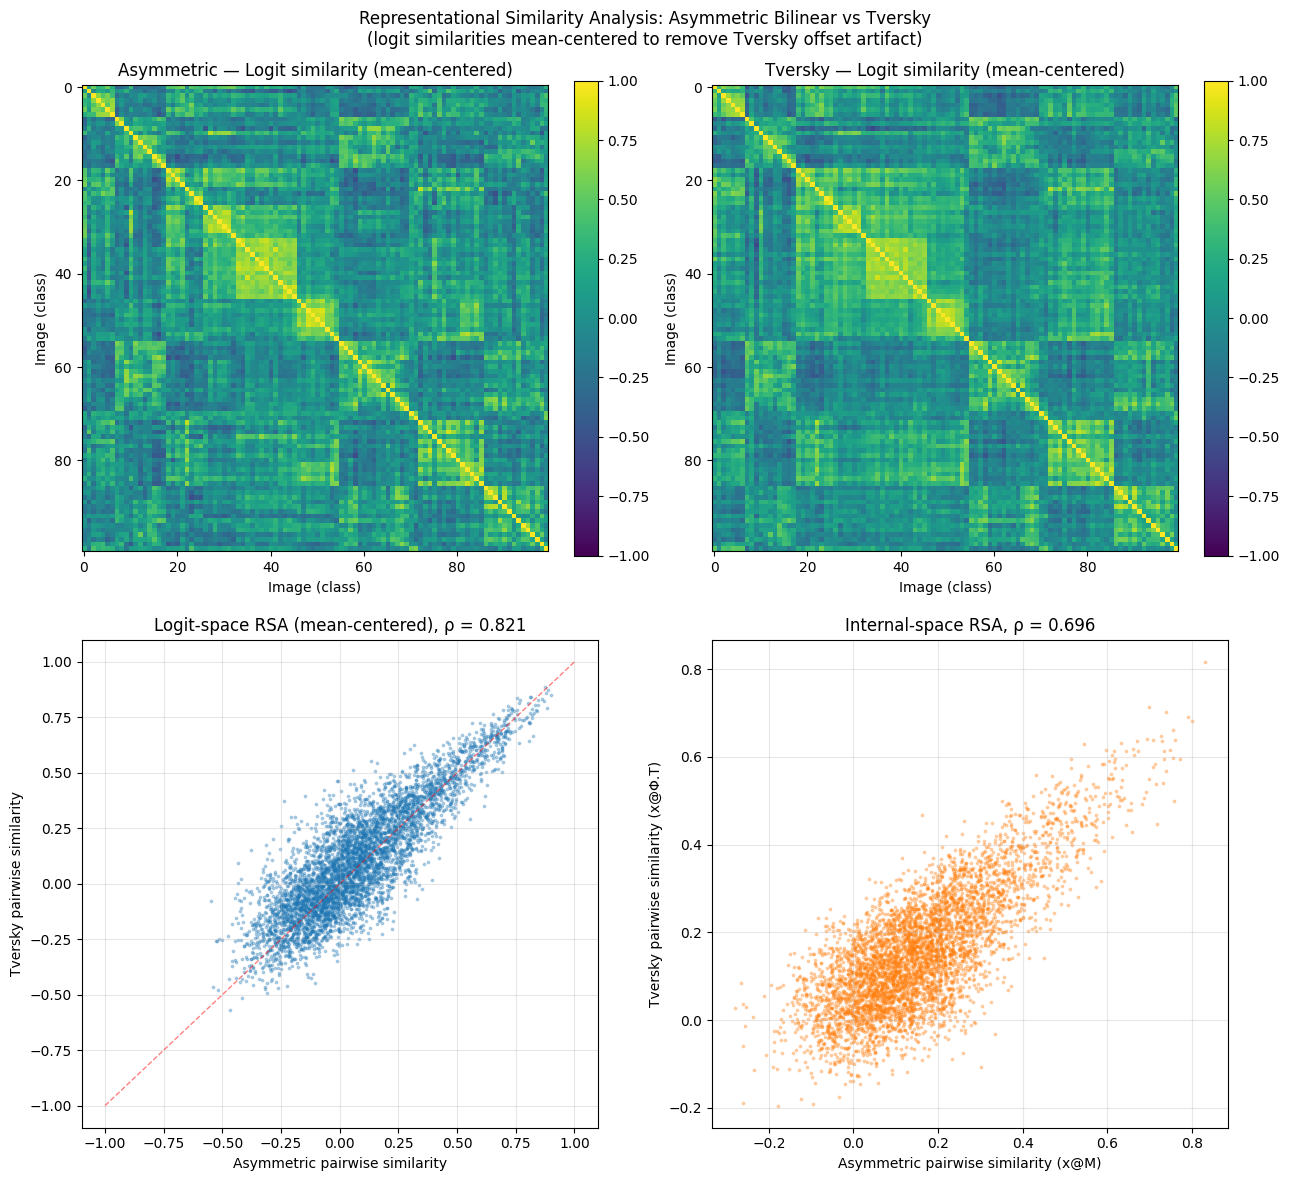

Saved corrected figure to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/rsa_comparison_corrected.png


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 12))

# Top row: CENTERED logit-space similarity matrices
im0 = axes[0, 0].imshow(sim_asym_logits_c.numpy(), cmap="viridis", vmin=-1, vmax=1)
axes[0, 0].set_title("Asymmetric — Logit similarity (mean-centered)")
axes[0, 0].set_xlabel("Image (class)")
axes[0, 0].set_ylabel("Image (class)")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(sim_tversky_logits_c.numpy(), cmap="viridis", vmin=-1, vmax=1)
axes[0, 1].set_title("Tversky — Logit similarity (mean-centered)")
axes[0, 1].set_xlabel("Image (class)")
axes[0, 1].set_ylabel("Image (class)")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# Bottom-left: centered logit-space scatter
axes[1, 0].scatter(tri_asym_logits_c, tri_tversky_logits_c, s=3, alpha=0.3)
axes[1, 0].set_xlabel("Asymmetric pairwise similarity")
axes[1, 0].set_ylabel("Tversky pairwise similarity")
axes[1, 0].set_title(f"Logit-space RSA (mean-centered), ρ = {r_s:.3f}")
axes[1, 0].plot([-1, 1], [-1, 1], "r--", alpha=0.5, linewidth=1)
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: internal-space scatter (unchanged, was already fine)
axes[1, 1].scatter(tri_asym_internal, tri_tversky_internal, s=3, alpha=0.3, color="C1")
axes[1, 1].set_xlabel("Asymmetric pairwise similarity (x@M)")
axes[1, 1].set_ylabel("Tversky pairwise similarity (x@Φ.T)")
axes[1, 1].set_title(f"Internal-space RSA, ρ = {r_spearman_int:.3f}")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Representational Similarity Analysis: Asymmetric Bilinear vs Tversky\n"
             "(logit similarities mean-centered to remove Tversky offset artifact)",
             fontsize=12)
plt.tight_layout()

plot_path = RESULTS_DIR / "rsa_comparison_corrected.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved corrected figure to {plot_path}")

In [19]:
rsa_results = {
    "logit_space_centered": {
        "pearson": float(r_p), "spearman": float(r_s),
        "note": "mean-centered to remove constant offset in Tversky logits",
    },
    "logit_space_raw_cosine": {
        "spearman": float(r_spearman_logit),
        "note": "ARTIFACT: Tversky logits cosine-degenerate (~1.0), do not use",
    },
    "internal_space": {
        "pearson": float(r_pearson_int), "spearman": float(r_spearman_int),
    },
    "calibration": {
        "asym_internal_vs_raw": float(rsa(tri_asym_internal, tri_raw)),
        "tversky_internal_vs_raw": float(rsa(tri_tversky_internal, tri_raw)),
    },
    "n_images": 100,
    "seed": 42,
}
with open(RESULTS_DIR / "rsa_results.json", "w") as f:
    json.dump(rsa_results, f, indent=2)
print("Updated RSA results saved.")

Updated RSA results saved.


In [20]:
# We need the cosine and symmetric models too. Define cosine, retrain both quickly.
class CosinePrototypeClassifier(nn.Module):
    def __init__(self, embed_dim=2048, n_classes=100, init_temperature=10.0):
        super().__init__()
        self.prototypes = nn.Parameter(torch.randn(n_classes, embed_dim))
        self.temperature = nn.Parameter(torch.tensor(float(init_temperature)))
    def forward(self, x):
        xn = F.normalize(x, p=2, dim=1)
        pn = F.normalize(self.prototypes, p=2, dim=1)
        return self.temperature * (xn @ pn.T)

# Cosine model, seed 42, 30 epochs (it converges slowly)
torch.manual_seed(42)
cosine_model = quick_train(CosinePrototypeClassifier(2048, 100), n_epochs=30)
cosine_model.eval()

# Symmetric model (gamma=0), seed 42, 20 epochs
torch.manual_seed(42)
symmetric_model = quick_train(AsymmetricBilinearClassifier(2048, 100, gamma=0.0), n_epochs=20)
symmetric_model.eval()

# Collect all four prototype banks (detached, on CPU)
prototype_banks = {
    "cosine": cosine_model.prototypes.detach().cpu(),
    "symmetric": symmetric_model.prototypes.detach().cpu(),
    "asymmetric": asym_model.prototypes.detach().cpu(),
    "tversky": tversky_model.prototypes.detach().cpu(),
}

for name, P in prototype_banks.items():
    print(f"{name:>12}: prototypes {tuple(P.shape)}, "
          f"norm range [{P.norm(dim=1).min():.2f}, {P.norm(dim=1).max():.2f}]")

      cosine: prototypes (100, 2048), norm range [1.76, 3.41]
   symmetric: prototypes (100, 2048), norm range [2.23, 3.57]
  asymmetric: prototypes (100, 2048), norm range [1.89, 3.13]
     tversky: prototypes (100, 2048), norm range [1.93, 2.25]


In [21]:
def prototype_centrality(prototypes, features, labels, n_classes=100):
    """
    For each class prototype, compute mean cosine similarity to its own-class
    held-out embeddings vs. to other-class embeddings.
    
    Returns per-class own-sim, other-sim, and margin (own - other).
    """
    # Normalize everything for cosine
    P_norm = F.normalize(prototypes, p=2, dim=1)      # [C, D]
    X_norm = F.normalize(features, p=2, dim=1)        # [N, D]
    
    # Cosine similarity of every embedding to every prototype: [N, C]
    sims = X_norm @ P_norm.T
    
    own_sims = []
    other_sims = []
    for c in range(n_classes):
        class_mask = (labels == c)
        # Similarity of class-c embeddings to prototype c
        own = sims[class_mask, c].mean().item()
        # Similarity of class-c embeddings to all OTHER prototypes
        other_protos = [j for j in range(n_classes) if j != c]
        other = sims[class_mask][:, other_protos].mean().item()
        own_sims.append(own)
        other_sims.append(other)
    
    own_sims = torch.tensor(own_sims)
    other_sims = torch.tensor(other_sims)
    margins = own_sims - other_sims
    return own_sims, other_sims, margins


print(f"{'Model':>12} | {'Own-class sim':>13} | {'Other-class sim':>15} | {'Margin':>8}")
print("-" * 60)

centrality_results = {}
for name, P in prototype_banks.items():
    own, other, margin = prototype_centrality(P, heldout_features.cpu(), heldout_labels.cpu())
    centrality_results[name] = {
        "own_mean": own.mean().item(),
        "other_mean": other.mean().item(),
        "margin_mean": margin.mean().item(),
        "margin_std": margin.std().item(),
        "own_per_class": own.tolist(),
        "margin_per_class": margin.tolist(),
    }
    print(f"{name:>12} | {own.mean():>13.4f} | {other.mean():>15.4f} | "
          f"{margin.mean():>7.4f}")

       Model | Own-class sim | Other-class sim |   Margin
------------------------------------------------------------
      cosine |        0.3829 |         -0.0032 |  0.3861
   symmetric |        0.1474 |         -0.0167 |  0.1640
  asymmetric |        0.1101 |         -0.0131 |  0.1233
     tversky |        0.0814 |          0.0277 |  0.0537


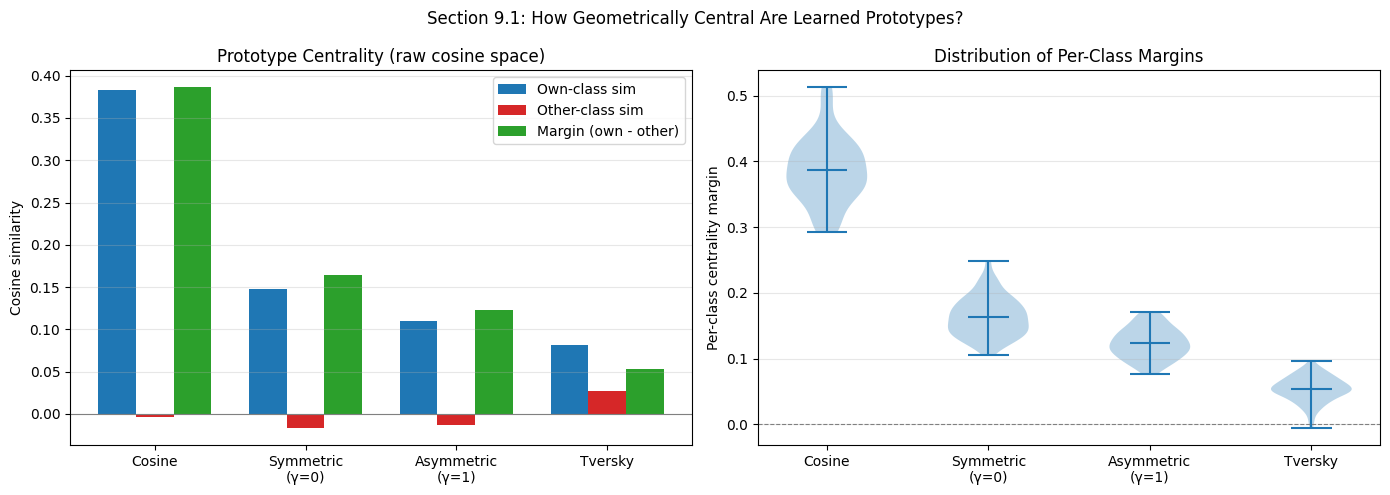

Saved to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/prototype_centrality.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ["cosine", "symmetric", "asymmetric", "tversky"]
display = {"cosine": "Cosine", "symmetric": "Symmetric\n(γ=0)",
           "asymmetric": "Asymmetric\n(γ=1)", "tversky": "Tversky"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of own vs other vs margin
x = np.arange(len(model_names))
width = 0.25
own = [centrality_results[m]["own_mean"] for m in model_names]
other = [centrality_results[m]["other_mean"] for m in model_names]
margin = [centrality_results[m]["margin_mean"] for m in model_names]

ax1.bar(x - width, own, width, label="Own-class sim", color="C0")
ax1.bar(x, other, width, label="Other-class sim", color="C3")
ax1.bar(x + width, margin, width, label="Margin (own - other)", color="C2")
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels([display[m] for m in model_names])
ax1.set_ylabel("Cosine similarity")
ax1.set_title("Prototype Centrality (raw cosine space)")
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# Right: per-class margin distributions (violin or box)
margin_data = [centrality_results[m]["margin_per_class"] for m in model_names]
parts = ax2.violinplot(margin_data, showmeans=True, showextrema=True)
ax2.set_xticks(range(1, len(model_names) + 1))
ax2.set_xticklabels([display[m] for m in model_names])
ax2.set_ylabel("Per-class centrality margin")
ax2.set_title("Distribution of Per-Class Margins")
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.grid(True, alpha=0.3, axis="y")

plt.suptitle("Section 9.1: How Geometrically Central Are Learned Prototypes?", fontsize=12)
plt.tight_layout()

plot_path = RESULTS_DIR / "prototype_centrality.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved to {plot_path}")

In [23]:
with open(RESULTS_DIR / "centrality_9_1.json", "w") as f:
    json.dump({
        m: {k: v for k, v in centrality_results[m].items()
            if k in ["own_mean", "other_mean", "margin_mean", "margin_std"]}
        for m in model_names
    }, f, indent=2)
print("Saved 9.1 results.")

Saved 9.1 results.


In [24]:
SEEDS = [42, 123, 7]

# Train asymmetric model for each seed, collect prototypes
asym_protos_by_seed = {}
tversky_protos_by_seed = {}

print("Training seeds for stability analysis...")
for seed in SEEDS:
    t0 = time.time()
    torch.manual_seed(seed)
    m = quick_train(AsymmetricBilinearClassifier(2048, 100, gamma=1.0), n_epochs=20)
    asym_protos_by_seed[seed] = m.prototypes.detach().cpu()
    print(f"  asymmetric seed {seed}: {time.time()-t0:.0f}s")

for seed in SEEDS:
    t0 = time.time()
    torch.manual_seed(seed)
    m = quick_train(TverskyProjectionLayer(2048, 100, n_features=224), n_epochs=10)
    tversky_protos_by_seed[seed] = m.prototypes.detach().cpu()
    print(f"  tversky seed {seed}: {time.time()-t0:.0f}s")

print("Done.")

Training seeds for stability analysis...
  asymmetric seed 42: 84s
  asymmetric seed 123: 84s
  asymmetric seed 7: 84s
  tversky seed 42: 155s
  tversky seed 123: 155s
  tversky seed 7: 155s
Done.


In [25]:
from itertools import combinations

def cross_seed_stability(protos_by_seed, seeds, n_classes=100):
    """
    For each class, compute mean pairwise cosine similarity of its prototype
    across all seed pairs. Returns per-class stability and the overall mean.
    """
    seed_pairs = list(combinations(seeds, 2))
    per_class_stability = []
    
    for c in range(n_classes):
        pair_sims = []
        for s1, s2 in seed_pairs:
            p1 = F.normalize(protos_by_seed[s1][c], p=2, dim=0)
            p2 = F.normalize(protos_by_seed[s2][c], p=2, dim=0)
            pair_sims.append((p1 @ p2).item())
        per_class_stability.append(sum(pair_sims) / len(pair_sims))
    
    per_class_stability = torch.tensor(per_class_stability)
    return per_class_stability


asym_stability = cross_seed_stability(asym_protos_by_seed, SEEDS)
tversky_stability = cross_seed_stability(tversky_protos_by_seed, SEEDS)

print(f"{'Model':>12} | {'Mean stability':>14} | {'Std':>7} | {'Min':>7} | {'Max':>7}")
print("-" * 60)
print(f"{'asymmetric':>12} | {asym_stability.mean():>14.4f} | {asym_stability.std():>7.4f} | "
      f"{asym_stability.min():>7.4f} | {asym_stability.max():>7.4f}")
print(f"{'tversky':>12} | {tversky_stability.mean():>14.4f} | {tversky_stability.std():>7.4f} | "
      f"{tversky_stability.min():>7.4f} | {tversky_stability.max():>7.4f}")

# Reference: what's the chance level? Cosine of two random 2048-d vectors ≈ 0
print(f"\nReference: random 2048-d vectors have expected cosine ≈ 0 "
      f"(±{1/math.sqrt(2048):.4f})")

       Model | Mean stability |     Std |     Min |     Max
------------------------------------------------------------
  asymmetric |         0.2134 |  0.0310 |  0.1240 |  0.2937
     tversky |         0.0449 |  0.0180 | -0.0010 |  0.0779

Reference: random 2048-d vectors have expected cosine ≈ 0 (±0.0221)


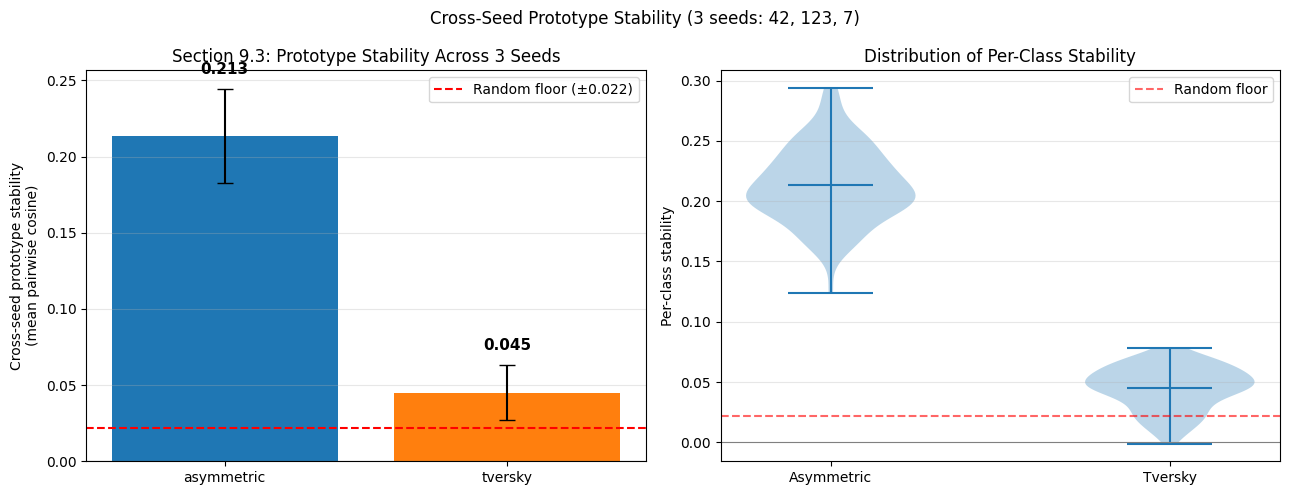

Saved to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/prototype_stability_9_3.png


In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar with the random reference line
models = ["asymmetric", "tversky"]
means = [asym_stability.mean().item(), tversky_stability.mean().item()]
stds = [asym_stability.std().item(), tversky_stability.std().item()]
random_ref = 1 / math.sqrt(2048)

bars = ax1.bar(models, means, yerr=stds, capsize=6, color=["C0", "C1"])
ax1.axhline(random_ref, color="red", linestyle="--",
            label=f"Random floor (±{random_ref:.3f})")
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.set_ylabel("Cross-seed prototype stability\n(mean pairwise cosine)")
ax1.set_title("Section 9.3: Prototype Stability Across 3 Seeds")
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax1.text(i, m + s + 0.01, f"{m:.3f}", ha="center", fontsize=11, fontweight="bold")

# Right: per-class stability distributions
ax2.violinplot([asym_stability.tolist(), tversky_stability.tolist()],
               showmeans=True, showextrema=True)
ax2.axhline(random_ref, color="red", linestyle="--", alpha=0.6,
            label=f"Random floor")
ax2.axhline(0, color="gray", linewidth=0.8)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(["Asymmetric", "Tversky"])
ax2.set_ylabel("Per-class stability")
ax2.set_title("Distribution of Per-Class Stability")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

plt.suptitle("Cross-Seed Prototype Stability (3 seeds: 42, 123, 7)", fontsize=12)
plt.tight_layout()

plot_path = RESULTS_DIR / "prototype_stability_9_3.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved to {plot_path}")

In [27]:
with open(RESULTS_DIR / "stability_9_3.json", "w") as f:
    json.dump({
        "asymmetric": {
            "mean": asym_stability.mean().item(),
            "std": asym_stability.std().item(),
            "min": asym_stability.min().item(),
            "max": asym_stability.max().item(),
        },
        "tversky": {
            "mean": tversky_stability.mean().item(),
            "std": tversky_stability.std().item(),
            "min": tversky_stability.min().item(),
            "max": tversky_stability.max().item(),
        },
        "random_floor": 1 / math.sqrt(2048),
        "seeds": SEEDS,
    }, f, indent=2)
print("Saved 9.3 results.")

Saved 9.3 results.
